In [1]:
import pandas as pd

## 1. Understanding the Basics

- What is Probability?
    - Probability is a measure of the likelihood that an event will occur. It ranges from 0 to 1, where 0 indicates an impossible event and 1 indicates a certain event.

- Key Probability Terminology:
    - **Experiment**: A process that leads to the occurrence of one and only one of several possible outcomes.
    - **Sample Space**: The set of all possible outcomes of an experiment.
    - **Event**: A subset of the sample space. It can consist of one or more outcomes.
    - **Random Variable**: A variable that takes on different values based on the outcome of a random event.
    - **Independent Events**: Two events are independent if the occurrence of one does not affect the probability of the other.
    - **Dependent Events**: Two events are dependent if the occurrence of one affects the probability
        of the other.
    - **Mutually Exclusive Events**: Two events are mutually exclusive if they cannot occur at the same time.
    - **Complementary Events**: Two events are complementary if they are mutually exclusive and their probabilities add up to 1.

- Give at least three probability event examples from the dataset.
    1. **Example 1**: Student passes the final exam 
    2. **Example 2**: Student Paticipated in group discussion and passed the exam.
    3. **Example 3**: student did not participate in group discussion and failed the exam.


## 2. Types of Events

In [2]:
df=pd.read_csv('C:\\Users\\ansh\\OneDrive\\Desktop\\Ansh\\rw\\rw\\MAS\\pr1\\student_exam_data.csv')
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,12,10,Yes,10,Pass
1,8,90,No,90,Pass
2,15,0,Yes,88,Pass
3,6,96,No,55,Fail
4,10,80,Yes,70,Pass


In [3]:
# Identify one empirical probability and one theoretical probability scenario from the dataset and calculate both.

# Empirical Probability: P(Student passes the final exam | Student joined group discussion) based on the data in the dataset.
# Theoretical Probability: P(Student passes the final exam | Student joined group discussion) based on the assumption that attending class regularly increases the chances of passing.

# Calculate Empirical Probability
joined_group_discussion = df[df['group_discussion'] == 'Yes']
passed_final = joined_group_discussion[joined_group_discussion['final_exam_pass'] == 'Pass']
empirical_probability = len(passed_final) / len(joined_group_discussion)

# Calculate Theoretical Probability
theoretical_probability = 0.8  # Assuming that attending class regularly increases the chances of passing to 80%
print(f"Empirical Probability: {empirical_probability:.2f}")
print(f"Theoretical Probability: {theoretical_probability:.2f}")

Empirical Probability: 0.73
Theoretical Probability: 0.80


## 3. Random Variable & Probability Distribution

    

In [4]:
# Define a random variable for the event “Number of students passing the final exam” out of 3 randomly selected students.
students = df.sample(n=3)
passed_students = students[students['final_exam_pass'] == 'Pass']
random_variable = len(passed_students)
print(random_variable)


# Construct its probability distribution table.
import scipy.stats as stats

n = 3
p_pass = len(df[df['final_exam_pass'] == 'Pass']) / len(df)

prob_dist = {}
for k in range(n + 1):
    prob_dist[k] = stats.binom.pmf(k, n, p_pass)

dist_df = pd.DataFrame({
    'X': list(prob_dist.keys()),
    'P(X=k)': list(prob_dist.values())
})

print(dist_df.to_string(index=False))

# Find the mean and variance of this random variable

mean = n * p_pass
variance = n * p_pass * (1 - p_pass)
print(f"Mean: {mean:.2f}")
print(f"Variance: {variance:.2f}")


2
 X  P(X=k)
 0   0.064
 1   0.288
 2   0.432
 3   0.216
Mean: 1.80
Variance: 0.72


## 4. Venn Diagram in Probability

- Draw a Venn diagram showing:
    - Students who study more than 10 hours/week.
    - Students who attend more than 80% of classes.
    - Overlap showing students who satisfy both conditions.


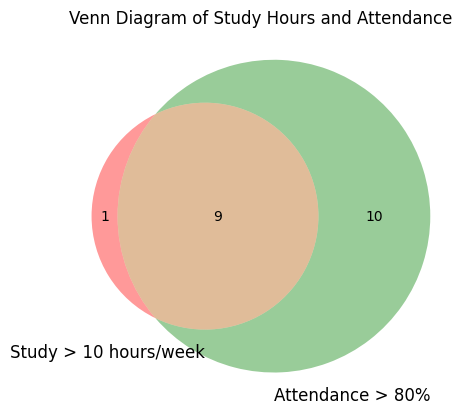

In [5]:
# Draw a Venn diagram showing:
# - Students who study more than 10 hours/week.
# - Students who attend more than 80% of classes.
# - Overlap showing students who satisfy both conditions.
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
studies_more_than_10_hours = set(df[df['study_hours'] > 10].index)
attends_more_than_80_percent = set(df[df['attendance'] > 0.8].index)
venn2([studies_more_than_10_hours, attends_more_than_80_percent], 
      set_labels=('Study > 10 hours/week', 'Attendance > 80%'))

plt.title('Venn Diagram of Study Hours and Attendance')
plt.show()

## 5. Contingency Table & Probability Calculations

In [6]:
# Create a contingency table for group_discussion (Yes/No) vs. final_exam_pass (Pass/Fail).

contingency_table = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
print(contingency_table)

# From the table, calculate:
#   - Joint probability of “Participates in group discussion AND Passes exam”.
#   - Marginal probability of “Passes exam”.
#   - Conditional probability of “Passes exam given participation in group discussion”.

joint_probability = contingency_table.loc['Yes', 'Pass'] / len(df)
marginal_probability = contingency_table['Pass'].sum() / len(df)
conditional_probability = contingency_table.loc['Yes', 'Pass'] / contingency_table.loc['Yes'].sum()

print(f"Joint Probability (Group Discussion AND Pass): {joint_probability:.2f}")
print(f"Marginal Probability (Pass): {marginal_probability:.2f}")
print(f"Conditional Probability (Pass | Group Discussion): {conditional_probability:.2f}")




final_exam_pass   Fail  Pass
group_discussion            
No                   5     4
Yes                  3     8
Joint Probability (Group Discussion AND Pass): 0.40
Marginal Probability (Pass): 0.60
Conditional Probability (Pass | Group Discussion): 0.73


## 6. Understanding Relationships

- Interpret conditional probability results in plain language (“intuition” behind the formula)
    - Conditional probability is the probability of an event occurring given that another event has already occurred. It helps us understand how the occurrence of one event affects the likelihood of another event. For example, if we want to find the probability that a student passes the final exam given that they attended more than 80% of classes, we can use conditional probability to calculate this. The formula for conditional probability is P(A|B) = P(A and B) / P(B), where A is the event of passing the exam and B is the event of attending more than 80% of classes. This allows us to see how attendance impacts the chances of passing the exam.

- Identify if “participating in group discussions” and “passing exam” are independent, dependent, or mutually exclusive events. Justify your answer.

    - If the probability of passing the exam is the same regardless of whether a student participated in group discussions or not, then the events are independent. This means that participating in group discussions does not affect the likelihood of passing the exam.

    - If the probability of passing the exam changes based on whether a student participated in group discussions, then the events are dependent. This would indicate that there is a relationship between participating in group discussions and passing the exam.

    - If it is impossible for a student to both participate in group discussions and pass the exam at the same time, then the events are mutually exclusive. However, in this case, it is likely that students can both participate in group discussions and pass the exam, so they are not mutually exclusive.

## 7. Bayes Theorem Application

In [8]:
# Suppose historical data shows:
#   - 70% of students who pass had high attendance (>80%).
#   - 40% of students who fail also had high attendance.
#   - 60% of all students had high attendance.

# Using Bayes Theorem, calculate the probability that a student with high attendance will pass the exam.
P_pass_given_high_attendance = (0.7 * 0.6) / ((0.7 * 0.6) + (0.4 * 0.4))
print(f"Probability of passing given high attendance: {P_pass_given_high_attendance:.2f}")

Probability of passing given high attendance: 0.72


#  Final Summary – Factors Affecting Probability of Passing

##  Final Exam Pass
- **Pass/Fail** is the outcome variable being measured.  
- **Pass** means the student succeeded; **Fail** means the student did not.  
- The probability of passing depends mainly on:  
  - Study hours  
  - Attendance  
  - Group discussion participation  
  - Previous test scores  



###  Study Hours
- More study time generally leads to a **higher chance of success**.  
- Fewer study hours often correlate with a **greater risk of failure**.

###  Attendance
- Strong attendance (above **80–90%**) significantly supports exam success.  
- Poor attendance reduces the **likelihood of passing**.

###  Group Discussion Participation
- Joining group discussions increases the **conditional probability** of passing (70% vs overall 65%).  
- This demonstrates the **positive effect of peer learning**.

###  Previous Test Scores
- Good past performance is a **strong predictor** of passing the final exam.  
- Weak prior scores often align with a **higher chance of failing**.
